<a href="https://colab.research.google.com/github/stanislawWojtas/Przetwarzanie-Obraz-w-Cyfrowych/blob/main/07_bilateral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Filtracja bilateralna

## Konwolucja obrazu z filtrem o zadanych współczynnikach

Splot (konwolucję) obrazu wejściowego $I$ z filtrem $\psi$ dla ustalonego punktu obrazu $\mathbf{x}$ można przedstawić następująco:

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||)I(\mathbf{p})
\end{equation}

gdzie:
- $\hat{I}$ jest obrazem wynikowym (przefiltrowanym),
- $W_N = \sum_y \psi(y)$ jest parametrem normalizującym współczynniki filtra $\psi$,
- $||\cdot||$ jest odległością między punktami obrazu $\mathbf{x}$ i $\mathbf{p}$ według ustalonej metryki (np. norma $L_2$). Uwaga, proszę pamiętać, że zarówno $\mathbf{x}$, jak i $\mathbf{p}$ to współrzędne przestrzenne,
- $\eta(\mathbf{x})$ jest otoczeniem punktu $\mathbf{x}$.

Funkcja $\psi$ decyduje o charakterze filtracji. Dla filtru Gaussowskiego:

\begin{equation}
\psi(y) = G_{\delta_s}(y)
\end{equation}

gdzie: $G_{\delta_s}(y)$ jest funkcją Gaussa z parametrem skali $\delta_s$.

Opisaną powyżej filtrację realizowaliśmy w ramach ćwiczenia "Przetwarzanie wstępne. Filtracja kontekstowa."

## Filtracja bilateralna

Wadą klasycznego splotu jest brak adaptacji współczynników filtra do lokalnego otoczenia $\eta(\mathbf{x})$ filtrowanego punktu $\mathbf{x}$.
Oznacza to wykorzystanie tych samych współczynników filtra $\psi$ niezależnie od tego czy otoczenie jest względnie jednorodne lub zawiera krawędzie obiektów (w tym przypadku dochodzi do "rozmywania" krawędzi).
Filtracja bilateralna uwzględnia lokalne otoczenie filtrowanego punktu, w ten sposób, że parametry filtra zmieniają się w zależności od "wyglądu" otocznia.


Współczynniki filtra obliczane są na podstawie odległości filtrowanego punktu $\mathbf{x}$ od każdego punktu otoczenia $\mathbf{p}$ w dziedzinie przestrzennej obrazu (tak jak przy typowym filtrze np. Gaussa) oraz odległości punktów w przeciwdziedzinie obrazu (np. na podstawie różnicy w jasności pikseli dla obrazu w odcieniach szarości):

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||) \gamma(|I(\mathbf{p}) - I(\mathbf{x})|) I(\mathbf{p})
\end{equation}
gdzie:
- $W_N$ jest współczynnikiem normalizującym filtr,
- $\gamma$ jest funkcją odległości w przeciwdziedzinie obrazu, np. $\gamma(y)=\exp(-\frac{y^2}{2\delta_r^2})$
- parametr $\delta_r$ jest utożsamiany z poziomem szumu w obrazie i należy go dobrać w sposób empiryczny.

Proszę chwilę zastanowić się nad powyższym równaniem, w szczególności nad funkcją $\gamma$. Proszę wyznaczyć, jaka będzie wartość funkcji dla pikseli podobnych (różnica 0, 1, 2), a skrajnie różnych (255, 200).

##  Realizacja ćwiczenia

### Wczytanie danych

1. Wczytaj dane z pliku *MR_data.mat*. W tym celu wykorzystaj funkcję `loadmat` z pakietu scipy:
        from scipy.io import loadmat
        mat = loadmat('MR_data.mat')

2. Wczytany plik zawiera 5 obrazów: *I_noisefree*, *I_noisy1*, *I_noisy2*, *I_noisy3* oraz *I_noisy4*. Odczytać je można w następujący sposób:
        Input = mat['I_noisy1']

3.Wyświetl wybrany obraz z pliku *MR_data.mat*. Zagadka - co to za obrazowanie medyczne?

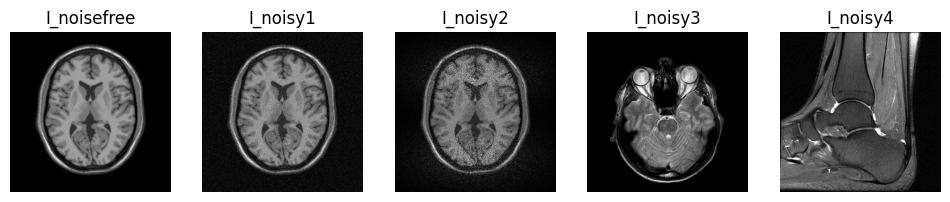

In [26]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np
from scipy import signal
from scipy.io import loadmat
import math

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/07_Bilateral/'

fileNames = ["MR_data.mat"]
for fileName in fileNames:
  if not os.path.exists(fileName):
      r = requests.get(url + fileName, allow_redirects=True)
      open(fileName, 'wb').write(r.content)

#TODO Samodzielna
mr_data = loadmat('MR_data.mat')
img_names = ['I_noisefree', 'I_noisy1', 'I_noisy2', 'I_noisy3', 'I_noisy4']
plt.figure(figsize=(12,5))
for i in range(len(img_names)):
  plt.subplot(1, len(img_names), i+1)
  plt.imshow(mr_data[img_names[i]], cmap='gray')
  plt.title(img_names[i])
  plt.axis('off')



### "Klasyczna" konwolucja

1. Zdefiniuj parametry filtra Gaussowskiego: rozmiar okna i wariancję $\delta_S$.
2. Oblicz współczynniki filtra na podstawie zdefiniowanych parametrów (najprościej w ramach podwójnej pętli for).
2. Sprawdź ich poprawność i zwizualizuj filtr (tak jak w ćwiczeniu pt. "Przetwarzanie wstępne. Filtracja kontekstowa.").
3. Wykonaj kopię obrazu wejściowego: `IConv = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentem tej funkcji są aktualnie przetwarzane okno i współczynniki filtra.
7. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.
8. Wyświetl wynik filtracji.
9. Porównaj wynik z obrazem oryginalnym.

In [27]:
# funkcje pomocnicze to wyświetlania maski
def mesh(fun, size):
    fig = plt.figure()
    ax = fig.add_subplot(projection = '3d')


    X = np.arange(-size//2, size//2, 1)
    Y = np.arange(-size//2, size//2, 1)
    X, Y = np.meshgrid(X, Y)
    Z = fun
    ax.plot_surface(X, Y, Z)
    plt.show()

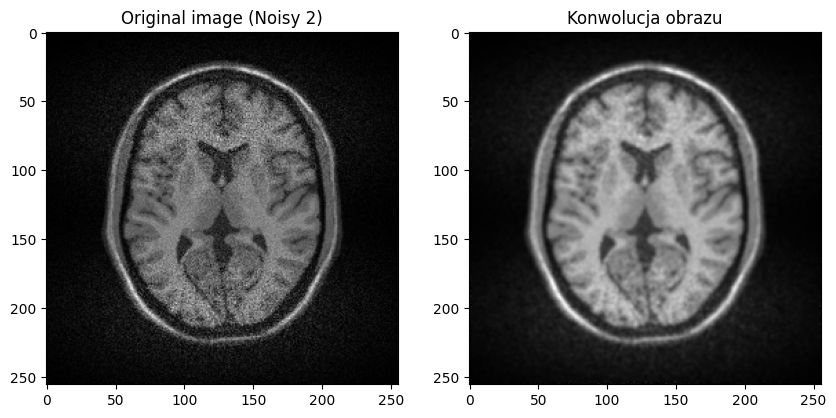

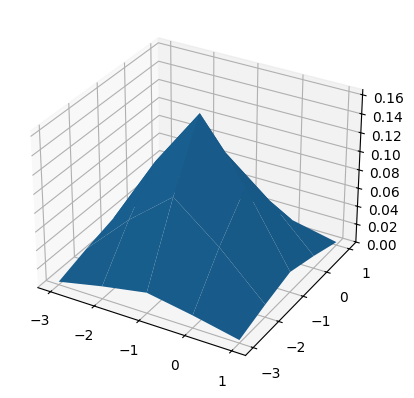

In [31]:
def classic_conv(image, window_size, s):
  if(window_size%2 == 0):
    raise ValueError("Window size must be odd")
  kernel_1D = signal.windows.gaussian(window_size, std=s)
  kernel_2D = np.outer(kernel_1D, kernel_1D)
  # Normalizacja filtra aby suma wag była równa 1
  kernel_2D = kernel_2D / kernel_2D.sum()

  Iconv = image.copy().astype(float)

  rows, cols = image.shape
  padding = window_size // 2  #dodany padding, żeby obraz mieścił się w filtrze

  for j in range(padding, rows - padding):
    for i in range(padding, cols - padding):
      neighborhood = image[j-padding:j+padding+1, i-padding : i+padding+1]
      Iconv[j, i] = np.sum(kernel_2D * neighborhood)

  Iconv = np.clip(Iconv, 0, 255)
  return Iconv.astype(np.uint8), kernel_2D


conv_image, gaussian_mask = classic_conv(mr_data['I_noisy2'], 5, 1)

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.imshow(mr_data['I_noisy2'], cmap='gray')
plt.title("Original image (Noisy 2)")
plt.subplot(1, 2, 2)
plt.imshow(conv_image, cmap='gray')
plt.title("Konwolucja obrazu")
mesh(gaussian_mask, 5)


### Filtracja bilateralna

1. Zdefiniuj dodatkowy parametr: wariancję $\delta_R$.
3. Wykonaj kopię obrazu wejściowego: `IBilateral = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentami funkcji są aktualnie przetwarzane okno, współczynniki filtra gausowskiego (takie same jak wcześniej) i wariancja $\delta_R$.
7. Oblicz odległość w przeciwdziedzinie (dla wartości pikseli).
8. Oblicz funkcję Gaussa dla obliczonych odległości z zadanym parametrem.
9. Wykonaj normalizację obliczonych współczynników.
10. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.
11. Wyświetl wynik filtracji.
12. Porównaj wynik z obrazem oryginalnym.

In [32]:
# s_r - wariancja
def bilateral_filtration(image, window_size, sigma, s_r):
  if(window_size%2 == 0):
      raise ValueError("Window Size must be odd")

  kernel_1D = signal.windows.gaussian(window_size, std=sigma)
  kernel_2D = np.outer(kernel_1D, kernel_1D)

  IBilateral = image.copy().astype(float)
  padding = window_size // 2
  rows, cols = image.shape

  for j in range(padding, rows - padding):
    for i in range(padding, cols - padding):
      neighborhood = image[j-padding:j+padding+1, i-padding : i+padding+1]

      # oblcizanie nowej wartości pixela
      IBilateral[j, i] = calc_new_pixel(neighborhood, kernel_2D, s_r)
  IBilateral = IBilateral.clip(0,255)
  return IBilateral.astype(np.uint8)


def calc_new_pixel(neighborhood, kernel, s_r):
  center_y, center_x = neighborhood.shape[0] // 2, neighborhood.shape[1] // 2
  center_value = neighborhood[center_y, center_x]

  # różnica wartości
  diff = neighborhood - center_value

  # funkcja gamma od jasności
  gamma = np.exp(-(diff**2) / (2 * s_r**2))

  final_weight = gamma * kernel

  #zwracamy znormalizowany wynik suma(wagi * wartości) / suma(wagi)
  return (np.sum(final_weight * neighborhood) / np.sum(final_weight))

Text(0.5, 1.0, 'Filtracja Bilateralna')

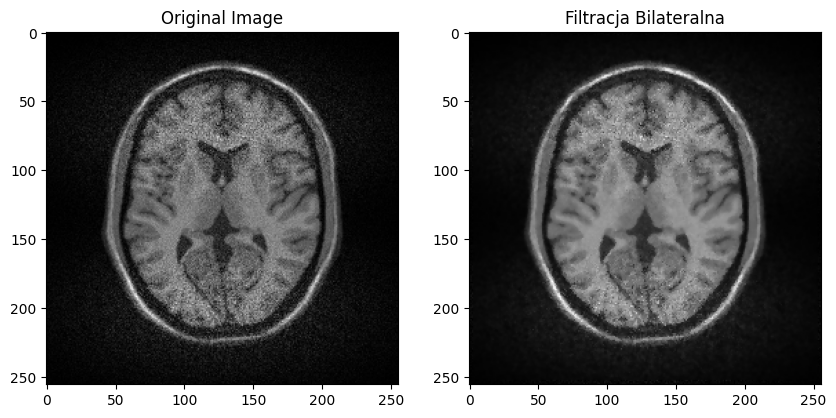

In [40]:
bilateral_image = bilateral_filtration(mr_data['I_noisy2'], 5, 1, 30)
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(mr_data['I_noisy2'], cmap='gray')
plt.title("Original Image")
plt.subplot(1,2,2)
plt.imshow(bilateral_image, cmap='gray')
plt.title("Filtracja Bilateralna")